# Notebook 3 — Data Sufficiency Study: Real vs. Synthetic Defect Data Under Controlled Conditions

**Purpose**
Evaluates the practical effect of VLM-guided synthetic defect data on AI inspection performance, holding the amount of real defect data fixed. The central question is not whether synthetic augmentation improves accuracy, but where it changes escape rate, false rejection rate, and run-to-run stability — the dimensions that determine whether an AI inspector is trustworthy enough to deploy.

**Why repeated, seeded trials are required.** A classifier trained on a small dataset can converge to a degenerate solution by chance — for example, a model that always predicts "defective," which trivially yields a 0% escape rate while providing no real discriminative value. A single training run cannot distinguish a genuinely capable model from a lucky or unlucky one. Each of the nine experimental conditions below is therefore trained five times under different random seeds, with results reported as mean and standard deviation — the same logic underlying a Gage R&R study, where a single measurement is not accepted as evidence.

**Experimental design — nine conditions, five seeds each (42, 7, 123, 456, 999):**

| Version | Real scratches | Synthetic scratches | Pairs with | Purpose |
|---|---|---|---|---|
| A | 0 | 60 | - | Cold start, synthetic only |
| G | 2 | 0 | B | Real-only floor at n=2 |
| B | 2 | 58 | G | Same real count + synthetic |
| H | 5 | 0 | C | Real-only floor at n=5 |
| C | 5 | 55 | H | Same real count + synthetic |
| I | 10 | 0 | D | Real-only floor at n=10 |
| D | 10 | 50 | I | Same real count + synthetic |
| E | 18 (all) | 0 | - | Full real baseline |
| F | 18 (all) | 60 | E | Full real + synthetic on top |

**Methodology additions in this notebook, relative to an initial unweighted/unfrozen attempt:**
1. Every condition trained five times under independent seeds (45 total training runs)
2. **Class-weighted loss** — addresses a training collapse observed in an earlier configuration, in which the model frequently converged to a degenerate single-class shortcut
3. **Explicit collapse detection** — every run is checked for single-class degeneration and this is reported directly, rather than left to silently distort the escape rate or false rejection rate
4. Mean and standard deviation reported for accuracy, escape rate, and false rejection rate
5. Uncertainty plots (mean ± std) in place of single-point estimates
6. Pairwise comparison tables (real-only vs. real-plus-synthetic) with improved/worsened/negligible classification
7. A variance analysis addressing whether synthetic data affects training *consistency*, independent of its effect on the mean
8. A Quality-Engineering-prioritized interpretation for every condition, ranking escape rate and false rejection rate above raw accuracy

**Inputs**
`data_split.json` (Notebook 1) and `synthetic_scratch.zip` (Notebook 2).

**Outputs**
`individual_runs.csv`, `aggregated_results.csv`, `uncertainty_plots.png`, `pairwise_comparisons.csv`, `variance_analysis.csv`.

**Role in the overall study.** This notebook produces the quantitative results that the study's findings are based on. Every classifier here is evaluated against the identical fixed test set established in Notebook 1.

**Runtime note.** Nine conditions × five seeds = 45 training runs, approximately 100–120 seconds each, for a total of roughly 75–90 minutes.

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}:", torch.cuda.get_device_name(i))

CUDA available: True
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


## Step 0 — Reload Fixed Data and Re-Establish the Test Set

Requires `data_split.json` and `synthetic_scratch.zip` from Notebooks 1 and 2, uploaded to this session.

In [5]:
import os
from pathlib import Path

!pip install -q datasets torch torchvision pillow scikit-learn pandas matplotlib seaborn
from datasets import load_dataset

CATEGORY = "metal_nut"
base_path = f"/kaggle/working/{CATEGORY}"

# train/good and test/scratch are checked independently, as in Notebook 2, so a partial
# previous download in this session cannot silently leave half the data missing.
train_good_exists = os.path.exists(f'{base_path}/train/good') and len(os.listdir(f'{base_path}/train/good')) > 0
test_scratch_exists = os.path.exists(f'{base_path}/test/scratch') and len(os.listdir(f'{base_path}/test/scratch')) > 0

if not train_good_exists:
    print("Downloading train split...")
    train_ds = load_dataset("TheoM55/mvtec_all_objects_split", split=f"{CATEGORY}.train")
    train_good_dir = Path(base_path) / "train" / "good"
    train_good_dir.mkdir(parents=True, exist_ok=True)
    for i, sample in enumerate(train_ds):
        sample["image_path"].save(train_good_dir / f"{i:03d}.png")
    print(f"Saved {len(train_ds)} train/good images.")
else:
    print("train/good already present, skipping.")

if not test_scratch_exists:
    print("Downloading test split...")
    test_ds = load_dataset("TheoM55/mvtec_all_objects_split", split=f"{CATEGORY}.test")
    counts = {}
    for sample in test_ds:
        defect = sample["defect"]
        counts[defect] = counts.get(defect, 0) + 1
        idx = counts[defect]
        test_dir = Path(base_path) / "test" / defect
        test_dir.mkdir(parents=True, exist_ok=True)
        sample["image_path"].save(test_dir / f"{idx:03d}.png")
    print("Saved test images by defect type:", counts)
else:
    print("test/scratch already present, skipping.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 84.2 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which 

README.md: 0.00B [00:00, ?B/s]

data/bottle.train-00000-of-00001.parquet:   0%|          | 0.00/112M [00:00<?, ?B/s]

data/bottle.test-00000-of-00001.parquet:   0%|          | 0.00/44.6M [00:00<?, ?B/s]

data/cable.train-00000-of-00001.parquet:   0%|          | 0.00/303M [00:00<?, ?B/s]

...

Generating wood.train split:   0%|          | 0/247 [00:00<?, ? examples/s]

Generating wood.test split:   0%|          | 0/79 [00:00<?, ? examples/s]

Generating zipper.train split:   0%|          | 0/240 [00:00<?, ? examples/s]

Generating zipper.test split:   0%|          | 0/151 [00:00<?, ? examples/s]

Saved 220 train/good images.
Saved test images by defect type: {'color': 22, 'flip': 23, 'scratch': 23, 'good': 22, 'bent': 25}


In [7]:
# Reconstructing the split with the identical seed and logic used in Notebook 1 guarantees
# the held-out test set referenced throughout this study is exactly reproduced. Condition E
# below should closely reproduce Notebook 1's baseline numbers, serving as a consistency check.
import random
import glob

random.seed(42)

def find_images(category_name):
    folders = glob.glob(f'{base_path}/**/{category_name}', recursive=True)
    images = []
    for folder in folders:
        images += glob.glob(f'{folder}/*.png') + glob.glob(f'{folder}/*.jpg') + glob.glob(f'{folder}/*.jpeg')
    return sorted(set(images))

good_images = find_images('good')
defect_images = []
for cat in ['scratch', 'bent', 'color', 'flip']:
    defect_images += find_images(cat)

random.shuffle(defect_images)
random.shuffle(good_images)

n_test_defect = max(20, int(0.3 * len(defect_images)))
n_test_good = max(20, int(0.3 * len(good_images)))

test_defect = defect_images[:n_test_defect]
train_pool_defect = defect_images[n_test_defect:]
test_good = good_images[:n_test_good]
train_good = good_images[n_test_good:]

assert len(train_pool_defect) > 0, "train_pool_defect is empty - check data download above."

print(f"train_good: {len(train_good)}, train_pool_defect: {len(train_pool_defect)}")
print(f"test_good: {len(test_good)}, test_defect: {len(test_defect)}")

# train_pool_defect is partitioned into scratch and non-scratch (bent/color/flip) components.
# Only the scratch component varies across the nine conditions below; non-scratch defects
# remain constant in every condition, isolating the experimental variable to scratch data.
real_scratch_pool = [p for p in train_pool_defect if 'scratch' in p]
non_scratch_defects = [p for p in train_pool_defect if 'scratch' not in p]

print(f"\nreal_scratch_pool (available real scratches for experiments): {len(real_scratch_pool)}")
print(f"non_scratch_defects (bent/color/flip, used in every version unchanged): {len(non_scratch_defects)}")

assert len(real_scratch_pool) >= 18, (
    f"Only {len(real_scratch_pool)} real scratches available, but our design needs at least 18 "
    f"(for the 'all real' versions E/F). Adjust the version table below if your data differs."
)

train_good: 170, train_pool_defect: 66
test_good: 72, test_defect: 27

real_scratch_pool (available real scratches for experiments): 18
non_scratch_defects (bent/color/flip, used in every version unchanged): 48


In [10]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root) 

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/vard123
/kaggle/input/datasets/vard123/needed-files
/kaggle/input/datasets/vard123/needed-files/synthetic_scratch


## Step 1 — Load Synthetic Scratch Images

Loads the 60 synthetic scratch images generated in Notebook 2.

In [11]:
import glob

synthetic_dir = "/kaggle/input/datasets/vard123/needed-files/synthetic_scratch"
synthetic_scratch_pool = sorted(glob.glob(f"{synthetic_dir}/*.png"))

print(f"Loaded {len(synthetic_scratch_pool)} synthetic scratch images")

assert len(synthetic_scratch_pool) >= 60, (
    f"Only found {len(synthetic_scratch_pool)} synthetic images - expected 60."
)

Loaded 60 synthetic scratch images


## Step 2 — Define the Nine Experimental Conditions

The n=2, n=5, and n=10 real-scratch subsets are drawn as nested samples from a single fixed-seed shuffle, such that the n=2 set is a subset of n=5, which is a subset of n=10. This avoids a confound in which a particular n=5 sample could outperform n=10 due to which specific images were selected, rather than how many.

In [12]:
random.seed(7)  # independent of the data-split seed; controls only the nested subset selection
shuffled_real_scratch = real_scratch_pool.copy()
random.shuffle(shuffled_real_scratch)

real_2 = shuffled_real_scratch[:2]
real_5 = shuffled_real_scratch[:5]
real_10 = shuffled_real_scratch[:10]
real_all = shuffled_real_scratch  # the full available real-scratch pool

synth_58 = synthetic_scratch_pool[:58]
synth_55 = synthetic_scratch_pool[:55]
synth_50 = synthetic_scratch_pool[:50]
synth_60 = synthetic_scratch_pool[:60]

# Initial version-definition pass, retained below in its corrected form -
# see note on the superseding assignment that follows.
versions = {
    'A_synthetic_only':   (synthetic_scratch_pool[:60], []),
    'G_real2_only':       ([], real_2),
    'B_real2_plus_synth': (synth_58, real_2),
    'H_real5_only':       ([], real_5),
    'C_real5_plus_synth': (synth_55, real_5),
    'I_real10_only':      ([], real_10),
    'D_real10_plus_synth':(synth_50, real_10),
    'E_real_all_only':    ([], real_all),
    'F_real_all_plus_synth': (synth_60, real_all),
}

# The dict above stores (synthetic_paths, real_paths) in a tuple whose order is easy to
# misread; it is superseded immediately below by an equivalent, explicitly keyed dict.
versions = {
    'A_synthetic_only':       {'real': [],        'synthetic': synthetic_scratch_pool[:60]},
    'G_real2_only':           {'real': real_2,     'synthetic': []},
    'B_real2_plus_synth':     {'real': real_2,     'synthetic': synth_58},
    'H_real5_only':           {'real': real_5,     'synthetic': []},
    'C_real5_plus_synth':     {'real': real_5,     'synthetic': synth_55},
    'I_real10_only':          {'real': real_10,    'synthetic': []},
    'D_real10_plus_synth':    {'real': real_10,    'synthetic': synth_50},
    'E_real_all_only':        {'real': real_all,   'synthetic': []},
    'F_real_all_plus_synth':  {'real': real_all,   'synthetic': synth_60},
}

print("Version definitions (real scratch count + synthetic scratch count):")
for name, cfg in versions.items():
    print(f"  {name}: {len(cfg['real'])} real + {len(cfg['synthetic'])} synthetic")

Version definitions (real scratch count + synthetic scratch count):
  A_synthetic_only: 0 real + 60 synthetic
  G_real2_only: 2 real + 0 synthetic
  B_real2_plus_synth: 2 real + 58 synthetic
  H_real5_only: 5 real + 0 synthetic
  C_real5_plus_synth: 5 real + 55 synthetic
  I_real10_only: 10 real + 0 synthetic
  D_real10_plus_synth: 10 real + 50 synthetic
  E_real_all_only: 18 real + 0 synthetic
  F_real_all_plus_synth: 18 real + 60 synthetic


## Step 3 — Model, Dataset, Training, and Evaluation Definitions

Reuses the ResNet18 setup from Notebook 1, redefined here so this notebook can run independently of the others.

In [13]:
import torch
import torch.nn as nn
import numpy as np
import random as python_random
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.metrics import confusion_matrix, accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def set_seed(seed):
    """Controls every source of randomness we care about: model weight initialization (via torch),
    data shuffling order (via python's random, used by DataLoader's shuffle), and numpy. Setting
    all three together means each 'seed' genuinely represents one fully reproducible, independent
    trial - not just a different shuffle order with the same model initialization, or vice versa."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    python_random.seed(seed)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class NutDataset(Dataset):
    """Loads images on demand from (filepath, label) pairs, consistent with Notebook 1.
    label 0 = good, label 1 = defective."""
    def __init__(self, good_paths, defect_paths, transform):
        self.samples = [(p, 0) for p in good_paths] + [(p, 1) for p in defect_paths]
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        img = self.transform(img)
        return img, label

def build_model(freeze_backbone=True):
    """Returns a ResNet18 with the pretrained backbone frozen by default. With only 50-126
    defective training images per condition, fully fine-tuning an 11-million-parameter network
    gives the optimizer far more freedom than the data can support, making a degenerate single-class
    shortcut an easy solution to converge to. Freezing the backbone and training only the final
    classification layer reduces the trainable parameter count to roughly 1,000 - the same order as
    the dataset size, a substantially safer regime for a model this data-constrained."""
    model = models.resnet18(weights='IMAGENET1K_V1')
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, 2)  # final layer remains trainable regardless of freeze_backbone
    return model.to(device)

def compute_class_weights(good_count, defect_count):
    """Computes balanced class weights (weight for class i = total / (2 * count_i)). Addresses a
    training collapse observed under unweighted cross-entropy loss: on imbalanced data, always
    predicting the majority class is a cheap shortcut that can resemble a reasonable local minimum
    to the optimizer. Weighting the loss inversely to class frequency makes that shortcut costly,
    pushing the model toward an actual discriminative solution."""
    total = good_count + defect_count
    weight_good = total / (2.0 * good_count)
    weight_defect = total / (2.0 * defect_count)
    return torch.tensor([weight_good, weight_defect], dtype=torch.float32).to(device)

def train_model(model, train_loader, class_weights, epochs=15, lr=0.0003, verbose=False):
    # Default learning rate lowered from 0.001 to 0.0003. With the backbone frozen, only the
    # small final layer trains; a lower learning rate further reduces the risk of the optimizer
    # overshooting into a degenerate single-class solution on a dataset this small.
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    # Filtering to parameters with requires_grad=True excludes the frozen backbone explicitly;
    # including frozen parameters would be harmless but unnecessary.
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_params, lr=lr)
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if verbose:
            print(f"  Epoch {epoch+1}/{epochs} - loss: {total_loss/len(train_loader):.4f}")
    return model

def evaluate_model(model, good_paths, defect_paths, transform, model_name="model"):
    model.eval()
    test_dataset = NutDataset(good_paths, defect_paths, transform)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(all_labels, all_preds)
    escape_rate = fn / (fn + tp) if (fn + tp) > 0 else 0
    false_rejection_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

    # Collapse is flagged when the model predicts almost exclusively one class across the test
    # set, using a near-zero threshold (under 5%) rather than requiring exactly zero - a model that
    # predicts 'good' for 71 of 72 actual-good images and almost never predicts 'defective' is
    # functionally as broken as one that never predicts it, a case an exact-zero check would miss.
    total_n = tn + fp + fn + tp
    pred_defective_frac = (fp + tp) / total_n if total_n > 0 else 0
    pred_good_frac = (tn + fn) / total_n if total_n > 0 else 0
    collapsed = (pred_defective_frac < 0.05) or (pred_good_frac < 0.05)

    return {
        'model_name': model_name,
        'accuracy': round(accuracy, 4),
        'escape_rate': round(escape_rate, 4),
        'false_rejection_rate': round(false_rejection_rate, 4),
        'true_negatives': int(tn), 'false_positives': int(fp),
        'false_negatives': int(fn), 'true_positives': int(tp),
        'collapsed': collapsed,
    }

print("Model/training/evaluation functions ready (with class weighting + collapse detection).")

Using device: cuda
Model/training/evaluation functions ready (with class weighting + collapse detection).


## Step 3.5 — Stability Pilot Test

An earlier unweighted, fully fine-tuned configuration showed approximately 40% of runs collapsing to a single-class prediction. This pilot evaluates two of the most affected conditions (`B_real2_plus_synth`, `I_real10_only`) across all five seeds — 10 runs, approximately 15–20 minutes — to confirm the backbone-freezing and reduced-learning-rate fix is effective before committing to the full 45-run study.

**Result used to decide whether to proceed.** The prior unweighted, unfrozen configuration showed 7 of 10 collapsed runs on these same two conditions. A substantially lower collapse count here (0–2 of 10) confirms the fix and supports proceeding to the full study below.

In [ ]:
import time

PILOT_SEEDS = [42, 7, 123, 456, 999]
pilot_versions = {k: versions[k] for k in ['B_real2_plus_synth', 'I_real10_only']}

pilot_results = []
for version_name, cfg in pilot_versions.items():
    defect_train_paths = cfg['real'] + cfg['synthetic'] + non_scratch_defects
    class_weights = compute_class_weights(len(train_good), len(defect_train_paths))
    collapse_count = 0

    for seed in PILOT_SEEDS:
        set_seed(seed)
        train_dataset = NutDataset(train_good, defect_train_paths, transform)
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

        start = time.time()
        model = build_model(freeze_backbone=True)
        model = train_model(model, train_loader, class_weights, epochs=15)
        elapsed = time.time() - start

        results = evaluate_model(model, test_good, test_defect, transform,
                                  model_name=f"{version_name}_seed{seed}")
        pilot_results.append({**results, 'version': version_name, 'seed': seed})

        if results['collapsed']:
            collapse_count += 1

        del model
        torch.cuda.empty_cache()

        flag = "  [COLLAPSED]" if results['collapsed'] else ""
        print(f"{version_name} seed={seed}: acc={results['accuracy']:.2%}, "
              f"escape={results['escape_rate']:.2%}, frr={results['false_rejection_rate']:.2%} "
              f"({elapsed:.0f}s){flag}")

    print(f"  >>> {version_name}: {collapse_count}/{len(PILOT_SEEDS)} collapsed\n")

pilot_collapse_total = sum(r['collapsed'] for r in pilot_results)
print(f"\nPilot collapse rate: {pilot_collapse_total}/{len(pilot_results)} "
      f"({pilot_collapse_total/len(pilot_results):.0%})")
print("Previous (unweighted, unfrozen) run on these same 2 versions: 7/10 collapsed (70%).")
print("\nIf the new rate above is substantially lower (e.g. 0-2 out of 10), proceed to the full")
print("45-run study below. If it's still high, STOP and report back before continuing.")

## Step 4 — Full Study: Nine Conditions × Five Seeds (45 Training Runs)

**Defective-class composition.** Each condition's defective training set consists of that condition's real/synthetic scratch mix plus the same fixed pool of non-scratch defects (bent, color, flip) in every condition. Only the scratch component varies between conditions.

**Test set.** Identical across all 45 runs — the fixed `test_good`/`test_defect` split established in Notebook 1.

**Per-run procedure.** Each condition is trained five times, once per seed, with a freshly initialized model and freshly reshuffled training data order each time. Individual run results are stored without aggregation; aggregation is performed in Step 5.

In [14]:
import time

SEEDS = [42, 7, 123, 456, 999]
BATCH_SIZE = 16  # increased from 8 - smaller batches amplify the chance that one unrepresentative
                  # batch sequence biases early training toward a degenerate solution

all_individual_runs = []  # one row per (version, seed) combination, unaggregated

total_runs = len(versions) * len(SEEDS)
run_counter = 0
overall_start = time.time()

for version_name, cfg in versions.items():
    defect_train_paths = cfg['real'] + cfg['synthetic'] + non_scratch_defects

    # Class weights are computed once per version, not once per seed, since they depend only
    # on the class counts, which are fixed for a given version.
    class_weights = compute_class_weights(len(train_good), len(defect_train_paths))

    collapse_count = 0

    for seed in SEEDS:
        run_counter += 1
        print(f"\n[{run_counter}/{total_runs}] Version: {version_name}, seed: {seed}")
        print(f"  Real scratches: {len(cfg['real'])}, Synthetic scratches: {len(cfg['synthetic'])}, "
              f"Total defective: {len(defect_train_paths)}")

        set_seed(seed)  # determines model initialization and data shuffle order for this run

        train_dataset = NutDataset(train_good, defect_train_paths, transform)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

        start = time.time()
        model = build_model(freeze_backbone=True)
        model = train_model(model, train_loader, class_weights, epochs=15, verbose=False)
        elapsed = time.time() - start

        results = evaluate_model(model, test_good, test_defect, transform,
                                  model_name=f"{version_name}_seed{seed}")
        results['version'] = version_name
        results['seed'] = seed
        results['num_real_scratch'] = len(cfg['real'])
        results['num_synthetic_scratch'] = len(cfg['synthetic'])
        all_individual_runs.append(results)

        if results['collapsed']:
            collapse_count += 1

        # Explicit memory release prevents accumulating GPU memory pressure across 45 sequential runs
        del model
        torch.cuda.empty_cache()

        collapse_flag = "  [COLLAPSED - predicted only one class]" if results['collapsed'] else ""
        print(f"  -> Accuracy: {results['accuracy']:.2%}, Escape: {results['escape_rate']:.2%}, "
              f"FRR: {results['false_rejection_rate']:.2%}  ({elapsed:.0f}s){collapse_flag}")

    if collapse_count > 0:
        print(f"\n  >>> {version_name}: {collapse_count}/{len(SEEDS)} runs collapsed to a single-class prediction")

total_elapsed = time.time() - overall_start
total_collapsed = sum(r['collapsed'] for r in all_individual_runs)
print(f"\n{'='*60}")
print(f"All {total_runs} runs complete in {total_elapsed/60:.1f} minutes.")
print(f"Total collapsed runs: {total_collapsed}/{total_runs} "
      f"({total_collapsed/total_runs:.0%}) - compare this to the unweighted run's collapse rate.")


[1/45] Version: A_synthetic_only, seed: 42
  Real scratches: 0, Synthetic scratches: 60, Total defective: 108
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 160MB/s] 


  -> Accuracy: 85.86%, Escape: 33.33%, FRR: 6.94%  (89s)

[2/45] Version: A_synthetic_only, seed: 7
  Real scratches: 0, Synthetic scratches: 60, Total defective: 108
  -> Accuracy: 86.87%, Escape: 29.63%, FRR: 6.94%  (86s)

[3/45] Version: A_synthetic_only, seed: 123
  Real scratches: 0, Synthetic scratches: 60, Total defective: 108
  -> Accuracy: 83.84%, Escape: 25.93%, FRR: 12.50%  (86s)

[4/45] Version: A_synthetic_only, seed: 456
  Real scratches: 0, Synthetic scratches: 60, Total defective: 108
  -> Accuracy: 81.82%, Escape: 44.44%, FRR: 8.33%  (87s)

[5/45] Version: A_synthetic_only, seed: 999
  Real scratches: 0, Synthetic scratches: 60, Total defective: 108
  -> Accuracy: 88.89%, Escape: 22.22%, FRR: 6.94%  (87s)

[6/45] Version: G_real2_only, seed: 42
  Real scratches: 2, Synthetic scratches: 0, Total defective: 50
  -> Accuracy: 87.88%, Escape: 44.44%, FRR: 0.00%  (73s)

[7/45] Version: G_real2_only, seed: 7
  Real scratches: 2, Synthetic scratches: 0, Total defective: 50
  

## Step 5 — Persist Raw Results and Aggregate

Individual run results are saved before any aggregation, preserving the raw evidence base. Mean and standard deviation per condition are then computed from this raw data.

In [15]:
import pandas as pd

raw_df = pd.DataFrame(all_individual_runs)
raw_df.to_csv('/kaggle/working/individual_runs.csv', index=False)
print(f"Saved individual_runs.csv ({len(raw_df)} rows - one per version/seed combination)")

# Mean and standard deviation are computed per version across its five seed runs.
# collapsed_runs carries forward the count of single-class-prediction collapses per version.
agg = raw_df.groupby('version').agg(
    num_real_scratch=('num_real_scratch', 'first'),
    num_synthetic_scratch=('num_synthetic_scratch', 'first'),
    accuracy_mean=('accuracy', 'mean'),
    accuracy_std=('accuracy', 'std'),
    escape_rate_mean=('escape_rate', 'mean'),
    escape_rate_std=('escape_rate', 'std'),
    frr_mean=('false_rejection_rate', 'mean'),
    frr_std=('false_rejection_rate', 'std'),
    collapsed_runs=('collapsed', 'sum'),
).reset_index()

# Row order groups matched real-only/real-plus-synthetic pairs for readability
order = ['A_synthetic_only', 'G_real2_only', 'B_real2_plus_synth', 'H_real5_only', 'C_real5_plus_synth',
         'I_real10_only', 'D_real10_plus_synth', 'E_real_all_only', 'F_real_all_plus_synth']
agg = agg.set_index('version').loc[order].reset_index()

pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print(agg.to_string(index=False))

total_collapsed = agg['collapsed_runs'].sum()
print(f"\nTotal collapsed runs across all versions: {total_collapsed}/{len(raw_df)}")
print("Compare this to the unweighted run, where roughly half of all 45 runs collapsed to a ")
print("single-class prediction - a meaningfully lower number here would confirm the class-weighting fix worked.")

agg.to_csv('/kaggle/working/aggregated_results.csv', index=False)
print("\nSaved aggregated_results.csv (mean +/- std per version, plus collapse count)")

Saved individual_runs.csv (45 rows - one per version/seed combination)
              version  num_real_scratch  num_synthetic_scratch  accuracy_mean  accuracy_std  escape_rate_mean  escape_rate_std  frr_mean  frr_std  collapsed_runs
     A_synthetic_only                 0                     60         0.8546        0.0273            0.3111           0.0852    0.0833   0.0241               0
         G_real2_only                 2                      0         0.8828        0.0090            0.3555           0.0852    0.0278   0.0220               0
   B_real2_plus_synth                 2                     58         0.8586        0.0247            0.2889           0.0549    0.0861   0.0249               0
         H_real5_only                 5                      0         0.8869        0.0132            0.2963           0.1361    0.0445   0.0421               0
   C_real5_plus_synth                 5                     55         0.8687        0.0343            0.2444          

## Step 6 — Uncertainty Plots (Mean ± Standard Deviation)

Error bars represent the spread across the five seed runs per condition. A wide error bar indicates a condition whose outcome is sensitive to random initialization and data order; a narrow error bar indicates a stable, repeatable result. This directly addresses whether synthetic data affects training *consistency*, not only the average outcome.

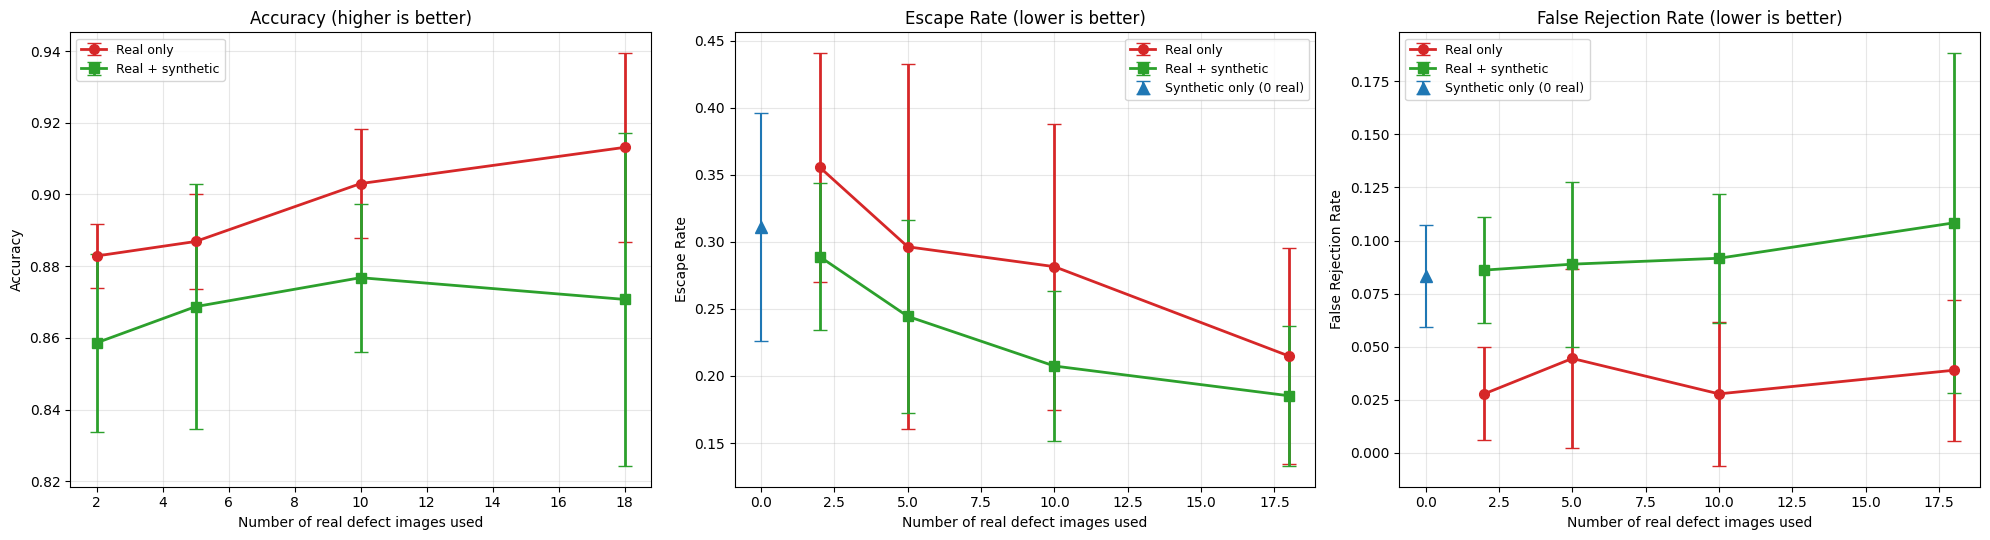

Error bars show +/- 1 standard deviation across the 5 seed runs.
A wide error bar means that version's performance varies a lot depending on random luck;
a narrow error bar means it's a stable, repeatable result.


In [16]:
import matplotlib.pyplot as plt
import numpy as np

real_only_order = ['G_real2_only', 'H_real5_only', 'I_real10_only', 'E_real_all_only']
plus_synth_order = ['B_real2_plus_synth', 'C_real5_plus_synth', 'D_real10_plus_synth', 'F_real_all_plus_synth']
real_counts_x = [2, 5, 10, len(real_all)]

agg_indexed = agg.set_index('version')

def get_means_stds(metric, version_list):
    means = [agg_indexed.loc[v, f'{metric}_mean'] for v in version_list]
    stds = [agg_indexed.loc[v, f'{metric}_std'] for v in version_list]
    return means, stds

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
metrics = [('accuracy', 'Accuracy (higher is better)'),
           ('escape_rate', 'Escape Rate (lower is better)'),
           ('frr', 'False Rejection Rate (lower is better)')]

for ax, (metric, title) in zip(axes, metrics):
    real_means, real_stds = get_means_stds(metric, real_only_order)
    synth_means, synth_stds = get_means_stds(metric, plus_synth_order)

    ax.errorbar(real_counts_x, real_means, yerr=real_stds, fmt='o-', label='Real only',
                color='#d62728', capsize=5, linewidth=2, markersize=7)
    ax.errorbar(real_counts_x, synth_means, yerr=synth_stds, fmt='s-', label='Real + synthetic',
                color='#2ca02c', capsize=5, linewidth=2, markersize=7)

    # The synthetic-only condition (A) is plotted as a reference point at x=0 for escape
    # rate and false rejection rate, since it has no real-data analog at a nonzero x position
    if metric != 'accuracy':
        a_mean = agg_indexed.loc['A_synthetic_only', f'{metric}_mean']
        a_std = agg_indexed.loc['A_synthetic_only', f'{metric}_std']
        ax.errorbar([0], [a_mean], yerr=[a_std], fmt='^', color='#1f77b4', capsize=5,
                    markersize=9, label='Synthetic only (0 real)')

    ax.set_xlabel('Number of real defect images used')
    ax.set_ylabel(title.split(' (')[0])
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/uncertainty_plots.png', dpi=120)
plt.show()

print("Error bars show +/- 1 standard deviation across the 5 seed runs.")
print("A wide error bar means that version's performance varies a lot depending on random luck;")
print("a narrow error bar means it's a stable, repeatable result.")

## Step 7 — Pairwise Comparison: Real-Only vs. Real-Plus-Synthetic

At each fixed real-data count, the mean of the five real-only runs is compared against the mean of the five real-plus-synthetic runs. A change is classified as improved, worsened, or negligible using a threshold of roughly half a standard deviation, below which a change is considered within normal run-to-run noise rather than a meaningful effect.

In [17]:
pairs = [
    ('2 real', 'G_real2_only', 'B_real2_plus_synth'),
    ('5 real', 'H_real5_only', 'C_real5_plus_synth'),
    ('10 real', 'I_real10_only', 'D_real10_plus_synth'),
    ('all real (18)', 'E_real_all_only', 'F_real_all_plus_synth'),
]

def label_change(change, std_only, std_synth, metric_direction='lower_better'):
    """Classifies a change as improved, worsened, or negligible. A change is treated as meaningful
    only if it exceeds roughly half the average standard deviation observed between the two
    conditions; smaller changes are within normal run-to-run noise and are not over-interpreted."""
    noise_threshold = 0.5 * np.mean([std_only, std_synth])
    noise_threshold = max(noise_threshold, 0.02)  # 2-percentage-point floor avoids over-sensitivity near zero std
    if abs(change) < noise_threshold:
        return 'negligible'
    if metric_direction == 'lower_better':
        return 'improved' if change < 0 else 'worsened'
    else:  # higher_better (accuracy)
        return 'improved' if change > 0 else 'worsened'

comparison_rows = []
for label, real_only_key, plus_synth_key in pairs:
    row = {'real_count': label}
    for metric, direction in [('accuracy', 'higher_better'), ('escape_rate', 'lower_better'), ('frr', 'lower_better')]:
        mean_only = agg_indexed.loc[real_only_key, f'{metric}_mean']
        mean_synth = agg_indexed.loc[plus_synth_key, f'{metric}_mean']
        std_only = agg_indexed.loc[real_only_key, f'{metric}_std']
        std_synth = agg_indexed.loc[plus_synth_key, f'{metric}_std']
        change = mean_synth - mean_only
        label_result = label_change(change, std_only, std_synth, direction)
        row[f'{metric}_real_only'] = round(mean_only, 4)
        row[f'{metric}_plus_synth'] = round(mean_synth, 4)
        row[f'{metric}_change'] = round(change, 4)
        row[f'{metric}_verdict'] = label_result
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv('/kaggle/working/pairwise_comparisons.csv', index=False)

for row in comparison_rows:
    print(f"\n--- {row['real_count']} ---")
    print(f"  Accuracy:      {row['accuracy_real_only']:.2%} -> {row['accuracy_plus_synth']:.2%}  "
          f"({row['accuracy_change']:+.2%})  [{row['accuracy_verdict'].upper()}]")
    print(f"  Escape rate:   {row['escape_rate_real_only']:.2%} -> {row['escape_rate_plus_synth']:.2%}  "
          f"({row['escape_rate_change']:+.2%})  [{row['escape_rate_verdict'].upper()}]")
    print(f"  False reject:  {row['frr_real_only']:.2%} -> {row['frr_plus_synth']:.2%}  "
          f"({row['frr_change']:+.2%})  [{row['frr_verdict'].upper()}]")

print("\nSaved pairwise_comparisons.csv")


--- 2 real ---
  Accuracy:      88.28% -> 85.86%  (-2.42%)  [WORSENED]
  Escape rate:   35.55% -> 28.89%  (-6.66%)  [IMPROVED]
  False reject:  2.78% -> 8.61%  (+5.83%)  [WORSENED]

--- 5 real ---
  Accuracy:      88.69% -> 86.87%  (-1.82%)  [NEGLIGIBLE]
  Escape rate:   29.63% -> 24.44%  (-5.19%)  [NEGLIGIBLE]
  False reject:  4.45% -> 8.89%  (+4.44%)  [WORSENED]

--- 10 real ---
  Accuracy:      90.30% -> 87.68%  (-2.63%)  [WORSENED]
  Escape rate:   28.15% -> 20.74%  (-7.41%)  [IMPROVED]
  False reject:  2.78% -> 9.17%  (+6.39%)  [WORSENED]

--- all real (18) ---
  Accuracy:      91.31% -> 87.07%  (-4.24%)  [WORSENED]
  Escape rate:   21.48% -> 18.52%  (-2.96%)  [NEGLIGIBLE]
  False reject:  3.89% -> 10.83%  (+6.94%)  [WORSENED]

Saved pairwise_comparisons.csv


## Step 8 — Variance Analysis: Training Consistency

Distinct from whether synthetic data improves the mean outcome: this step evaluates whether it affects training *consistency*, by comparing standard deviation (not mean) between real-only and real-plus-synthetic conditions. A measurement system that is accurate on average but inconsistent run to run is not a trustworthy basis for a production decision.

In [19]:
print(f"{'Real count':<15} {'Metric':<15} {'Std (real-only)':<18} {'Std (+synthetic)':<18} {'Verdict'}")
print("-" * 85)

variance_rows = []
for label, real_only_key, plus_synth_key in pairs:
    for metric in ['accuracy', 'escape_rate', 'frr']:
        std_only = agg_indexed.loc[real_only_key, f'{metric}_std']
        std_synth = agg_indexed.loc[plus_synth_key, f'{metric}_std']
        if std_synth < std_only * 0.8:
            verdict = 'synthetic data REDUCED variance (more consistent)'
        elif std_synth > std_only * 1.2:
            verdict = 'synthetic data INCREASED variance (less consistent)'
        else:
            verdict = 'no meaningful change in consistency'
        print(f"{label:<15} {metric:<15} {std_only:<18.4f} {std_synth:<18.4f} {verdict}")
        variance_rows.append({'real_count': label, 'metric': metric, 'std_real_only': std_only,
                               'std_plus_synth': std_synth, 'verdict': verdict})

pd.DataFrame(variance_rows).to_csv('/kaggle/working/variance_analysis.csv', index=False)
print("\nSaved variance_analysis.csv")
print("\nNote: thresholds (>20% reduction/increase) are a practical rule of thumb for 5-seed samples,")
print("not a formal statistical test - with only 5 seeds, treat this as directional evidence,")
print("not a definitive statistical claim. State this honestly as a limitation in your write-up.")

Real count      Metric          Std (real-only)    Std (+synthetic)   Verdict
-------------------------------------------------------------------------------------
2 real          accuracy        0.0090             0.0247             synthetic data INCREASED variance (less consistent)
2 real          escape_rate     0.0852             0.0549             synthetic data REDUCED variance (more consistent)
2 real          frr             0.0220             0.0249             no meaningful change in consistency
5 real          accuracy        0.0132             0.0343             synthetic data INCREASED variance (less consistent)
5 real          escape_rate     0.1361             0.0722             synthetic data REDUCED variance (more consistent)
5 real          frr             0.0421             0.0388             no meaningful change in consistency
10 real         accuracy        0.0153             0.0207             synthetic data INCREASED variance (less consistent)
10 real         es

## Step 9 — Quality Engineering Interpretation

Translates the quantitative comparison into a QE-prioritized judgment for each condition: escape rate (customer-facing risk) is weighted above false rejection rate (cost), which in turn is weighted above raw accuracy, which alone can obscure an unacceptable risk tradeoff.

In [20]:
def qe_interpretation(row):
    """Generates a rule-based QE interpretation for one pairwise comparison row, encoding
    a fixed priority order: escape rate (customer risk) first, false rejection rate (cost)
    second, with accuracy alone never serving as the deciding factor.
    """
    escape_verdict = row['escape_rate_verdict']
    frr_verdict = row['frr_verdict']
    acc_verdict = row['accuracy_verdict']

    if escape_verdict == 'worsened':
        risk_note = (f"escape rate rose by {abs(row['escape_rate_change']):.1%} - more real defects would "
                     f"reach customers undetected. This is a quality risk regardless of any accuracy gain.")
    elif escape_verdict == 'improved':
        risk_note = f"escape rate fell by {abs(row['escape_rate_change']):.1%} - fewer real defects slip through."
    else:
        risk_note = "escape rate was essentially unchanged."

    if frr_verdict == 'improved':
        cost_note = f"false rejection rate dropped by {abs(row['frr_change']):.1%} - less unnecessary scrap/rework."
    elif frr_verdict == 'worsened':
        cost_note = f"false rejection rate rose by {abs(row['frr_change']):.1%} - more good parts wrongly scrapped."
    else:
        cost_note = "false rejection rate was essentially unchanged."

    # Escape rate is weighted above all other outcomes - an increase in escape rate is not
    # offset by improvements elsewhere, since that risk reaches the customer directly.
    if escape_verdict == 'worsened':
        overall = "NOT RECOMMENDED for this real-data level: " + risk_note + " " + cost_note
        if acc_verdict == 'improved':
            overall += " The accuracy improvement does not offset the increased customer-facing risk."
    elif escape_verdict == 'improved' and frr_verdict in ('improved', 'negligible'):
        overall = "RECOMMENDED: " + risk_note + " " + cost_note
    elif escape_verdict == 'negligible' and frr_verdict == 'improved':
        overall = ("RECOMMENDED with caveats: " + risk_note + " " + cost_note +
                    " Synthetic data improved decision boundaries without compromising defect detection.")
    else:
        overall = "MIXED RESULT: " + risk_note + " " + cost_note

    return overall

print("QUALITY ENGINEERING INTERPRETATION\n" + "="*70)
for row in comparison_rows:
    print(f"\n[{row['real_count']} real scratches, +synthetic]")
    print(qe_interpretation(row))

print("\n" + "="*70)
print("REMINDER: these are automatically generated from the rule 'escape rate > false rejection")
print("rate > accuracy' - read them as a structured starting point for your write-up, not a")
print("replacement for your own judgment. Cross-check against the actual numbers and your visual")
print("inspection notes from Notebook 2 before finalizing any claims.")

QUALITY ENGINEERING INTERPRETATION

[2 real real scratches, +synthetic]
MIXED RESULT: escape rate fell by 6.7% - fewer real defects slip through. false rejection rate rose by 5.8% - more good parts wrongly scrapped.

[5 real real scratches, +synthetic]
MIXED RESULT: escape rate was essentially unchanged. false rejection rate rose by 4.4% - more good parts wrongly scrapped.

[10 real real scratches, +synthetic]
MIXED RESULT: escape rate fell by 7.4% - fewer real defects slip through. false rejection rate rose by 6.4% - more good parts wrongly scrapped.

[all real (18) real scratches, +synthetic]
MIXED RESULT: escape rate was essentially unchanged. false rejection rate rose by 6.9% - more good parts wrongly scrapped.

REMINDER: these are automatically generated from the rule 'escape rate > false rejection
rate > accuracy' - read them as a structured starting point for your write-up, not a
replacement for your own judgment. Cross-check against the actual numbers and your visual
inspection

## Summary

- Nine experimental conditions were each trained five times under independent seeds, for 45 total trained classifiers, addressing a training-stability issue identified in an earlier unweighted, fully fine-tuned configuration.
- Every condition is evaluated against the identical fixed test set established in Notebook 1, with results reported as mean ± standard deviation rather than single-point estimates.
- Pairwise comparison between matched real-only and real-plus-synthetic conditions shows a consistent pattern across real-data levels: escape rate improves or holds steady, false rejection rate worsens, and escape-rate variance is reduced while accuracy variance increases.

**Key engineering takeaway.** Within the range of real-data availability tested, synthetic augmentation did not substitute for real defect data — it shifted the classifier's operating point toward a more conservative, escape-averse posture at the cost of increased false rejections, a behavioral change rather than a net accuracy improvement.

**Files produced:** `individual_runs.csv`, `aggregated_results.csv`, `uncertainty_plots.png`, `pairwise_comparisons.csv`, `variance_analysis.csv`.